# Análisis de entrada para LavaSimio

## Notebook v2

Este notebook es una guía de estudio interactiva para reconstruir el análisis de entrada de un sistema de lavandería que recibe órdenes agrupadas en bolsas de tres tipos de ropa: blanca, color y delicada.

La versión anterior del notebook requería corrección en la sección de comparación de modelos de conteos diarios. El problema no afectaba la selección final del modelo, pero sí el soporte estadístico usado para justificarla: la binomial negativa condicionada por día de semana se había reportado con una log-verosimilitud y un AIC incompatibles con la conclusión. Aquí se re-estima la fila con una verosimilitud estable y se agregan diagnósticos que respaldan el modelo seleccionado.

**Flujo del notebook:** carga y validación de datos → exploración → ajuste de llegadas → diagnósticos → atributos de órdenes → bolsas totales → composición de bolsas → generador de simulación → validación y escenarios.

**Modelo recomendado:** proceso de Poisson no homogéneo por día de semana y hora; segmento condicionado a día/hora; tipo de servicio condicionado a segmento; bolsas totales por celda segmento×servicio; composición Dirichlet-multinomial por celda, con excepción multinomial para restaurante·rápido.

In [32]:
# Instalar dependencias
!pip install ipywidgets

In [33]:
# Librerías base
import io
import math
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special, stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RNG_SEED = 20260609
rng = np.random.default_rng(RNG_SEED)

print("Entorno preparado. Semilla aleatoria:", RNG_SEED)

Entorno preparado. Semilla aleatoria: 20260609


## 1. Carga de datos

El notebook intenta cargar el CSV desde el directorio de trabajo. Si no lo encuentra, usa la copia comprimida incrustada en esta misma libreta. Esto permite compartir el notebook como archivo autónomo, aunque se recomienda mantener el CSV original junto a la libreta para trazabilidad.

In [34]:
def load_orders(csv_path=None):
    """Carga el CSV de órdenes."""
    df_loaded = pd.read_csv("https://raw.githubusercontent.com/simulemos/sa/refs/heads/main/datos/1a.LavaSimio_2025.csv")
    return df_loaded, "https://github.com/simulemos"

raw_df, source = load_orders()
print(f"Datos cargados desde: {source}")
print(f"Filas: {len(raw_df):,} | Columnas: {len(raw_df.columns)}")
display(raw_df.head())

Datos cargados desde: https://github.com/simulemos
Filas: 26,270 | Columnas: 9


,id_orden,id_cliente,segmento_cliente,fecha_hora_llegada,tipo_servicio,bolsas_delicada,bolsas_color,bolsas_blanca,bolsas_total
0,O2025-000001,C119,restaurante,2025-01-01 05:56:28,normal,0,5,0,5
1,O2025-000002,C158,restaurante,2025-01-01 06:45:00,normal,0,1,1,2
2,O2025-000003,C080,gimnasio,2025-01-01 07:10:26,normal,0,5,0,5
3,O2025-000004,C030,hotel,2025-01-01 07:34:07,normal,0,0,1,1
4,O2025-000005,C101,gimnasio,2025-01-01 07:43:35,normal,0,3,3,6


## 2. Preparación y calidad de datos

La preparación es deliberadamente mínima: no se imputan valores, no se eliminan registros y los timestamps repetidos se conservan como llegadas simultáneas. Se derivan variables de calendario para el análisis de llegadas.

In [35]:
# Normalización de tipos y variables derivadas
required_cols = [
    "id_orden", "id_cliente", "segmento_cliente", "fecha_hora_llegada", "tipo_servicio",
    "bolsas_delicada", "bolsas_color", "bolsas_blanca", "bolsas_total"
]
missing_cols = [c for c in required_cols if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Columnas faltantes: {missing_cols}")

df = raw_df.copy()
df["fecha_hora_llegada"] = pd.to_datetime(df["fecha_hora_llegada"])
df = df.sort_values("fecha_hora_llegada").reset_index(drop=True)

df["fecha"] = df["fecha_hora_llegada"].dt.floor("D")
df["mes"] = df["fecha_hora_llegada"].dt.month
df["dow"] = df["fecha_hora_llegada"].dt.weekday  # lunes=0
DOW_NAMES = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
df["dia_semana"] = pd.Categorical(df["dow"].map(dict(enumerate(DOW_NAMES))), categories=DOW_NAMES, ordered=True)
df["hora"] = df["fecha_hora_llegada"].dt.hour

calendar = pd.date_range(df["fecha"].min(), df["fecha"].max(), freq="D")
daily_orders = df.groupby("fecha").size().reindex(calendar, fill_value=0)
daily_df = pd.DataFrame({"fecha": calendar, "ordenes": daily_orders.values})
daily_df["dow"] = daily_df["fecha"].dt.weekday
daily_df["dia_semana"] = pd.Categorical(daily_df["dow"].map(dict(enumerate(DOW_NAMES))), categories=DOW_NAMES, ordered=True)
daily_df["mes"] = daily_df["fecha"].dt.month

segments = np.array(sorted(df["segmento_cliente"].unique()))
services = np.array(["normal", "rápido"])
hours = np.arange(df["hora"].min(), df["hora"].max() + 1)

qc = pd.DataFrame({
    "Chequeo": [
        "Registros / órdenes únicas",
        "Clientes únicos / segmentos",
        "Días cubiertos",
        "Valores faltantes",
        "Filas duplicadas completas / IDs duplicados",
        "Timestamps duplicados",
        "Errores en suma de bolsas / órdenes con total < 1",
        "Horario operativo observado",
    ],
    "Resultado": [
        f"{len(df):,} / {df['id_orden'].nunique():,}",
        f"{df['id_cliente'].nunique():,} / {df['segmento_cliente'].nunique():,}",
        f"{len(calendar):,} ({df['fecha_hora_llegada'].min()} a {df['fecha_hora_llegada'].max()})",
        f"{int(df.isna().sum().sum()):,}",
        f"{int(df.duplicated().sum()):,} / {int(df['id_orden'].duplicated().sum()):,}",
        f"{int(df['fecha_hora_llegada'].duplicated().sum()):,}",
        f"{int((df[['bolsas_delicada','bolsas_color','bolsas_blanca']].sum(axis=1) != df['bolsas_total']).sum()):,} / {int((df['bolsas_total'] < 1).sum()):,}",
        f"{df['hora'].min():02d}:00 a {df['hora'].max():02d}:59",
    ]
}).set_index("Chequeo")

display(qc)

,Resultado
Chequeo,
Registros / órdenes únicas,"26,270 / 26,270"
Clientes únicos / segmentos,160 / 4
Días cubiertos,365 (2025-01-01 05:56:28 a 2025-12-31 21:25:37)
Valores faltantes,0
Filas duplicadas completas / IDs duplicados,0 / 0
Timestamps duplicados,23
Errores en suma de bolsas / órdenes con total < 1,0 / 0
Horario operativo observado,05:00 a 23:59


In [36]:
# Segmentos, servicio y clientes
seg_summary = (
    df.groupby("segmento_cliente")
      .agg(
          ordenes=("id_orden", "count"),
          clientes=("id_cliente", "nunique"),
          normal=("tipo_servicio", lambda s: int((s == "normal").sum())),
          rapido=("tipo_servicio", lambda s: int((s == "rápido").sum())),
      )
      .assign(
          pct_total=lambda x: 100 * x["ordenes"] / x["ordenes"].sum(),
          pct_rapido=lambda x: 100 * x["rapido"] / x["ordenes"],
      )
      .sort_values("ordenes", ascending=False)
)

display(seg_summary[["ordenes", "pct_total", "normal", "rapido", "pct_rapido", "clientes"]].round(2))

client_counts = df.groupby("id_cliente").size().sort_values(ascending=False)
print(f"Órdenes por cliente: media={client_counts.mean():.1f}, mediana={client_counts.median():.0f}, rango={client_counts.min()}–{client_counts.max()}")
print(f"Concentración top 10 clientes: {100 * client_counts.head(10).sum() / len(df):.1f}%")
print(f"Concentración top 20 clientes: {100 * client_counts.head(20).sum() / len(df):.1f}%")

,ordenes,pct_total,normal,rapido,pct_rapido,clientes
segmento_cliente,,,,,,
hotel,8849,33.68,8391,458,5.18,30
restaurante,6278,23.90,4968,1310,20.87,55
clínica,6065,23.09,5142,923,15.22,35
gimnasio,5078,19.33,4527,551,10.85,40


Órdenes por cliente: media=164.2, mediana=140, rango=51–489
Concentración top 10 clientes: 15.4%
Concentración top 20 clientes: 26.8%


## 3. Exploración de llegadas

Primero se observan tres patrones esenciales para una simulación de capacidad: nivel diario, estacionalidad semanal y perfil intradiario. Una única distribución de interarribos para todo el año mezclaría horas de apertura, horas pico y días de baja demanda; por eso se modelan tasas por día de semana y hora.

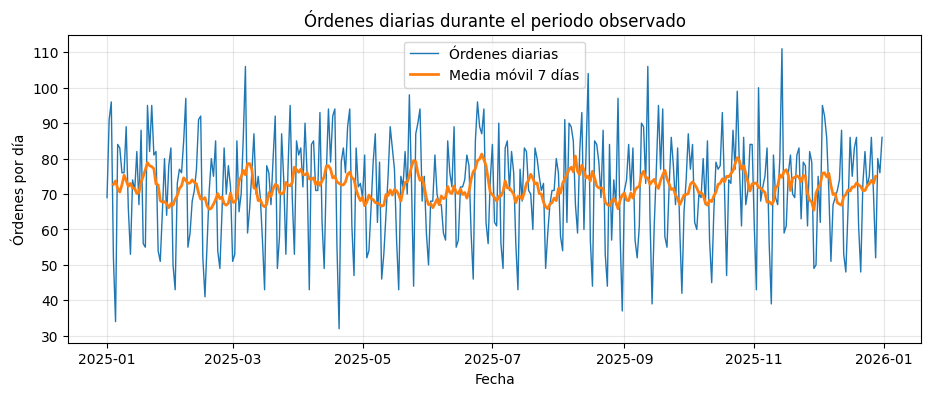

In [37]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_df["fecha"], daily_df["ordenes"], linewidth=1, label="Órdenes diarias")
ax.plot(daily_df["fecha"], daily_df["ordenes"].rolling(7, center=True).mean(), linewidth=2, label="Media móvil 7 días")
ax.set_title("Órdenes diarias durante el periodo observado")
ax.set_ylabel("Órdenes por día")
ax.set_xlabel("Fecha")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_19630/2037434098.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=DOW_NAMES, showfliers=True)


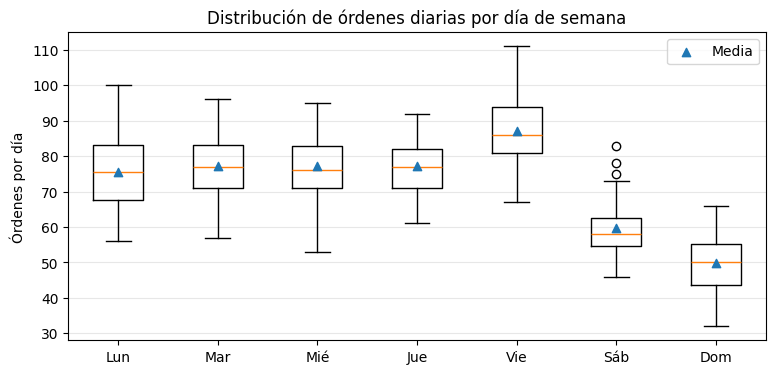

,count,mean,std,min,median,max
dia_semana,,,,,,
Lun,52,75.65,9.64,56,75.5,100
Mar,52,77.23,8.64,57,77.0,96
Mié,53,77.09,9.54,53,76.0,95
Jue,52,77.12,7.81,61,77.0,92
Vie,52,87.04,9.74,67,86.0,111
Sáb,52,59.65,7.99,46,58.0,83
Dom,52,49.92,7.77,32,50.0,66


In [38]:
fig, ax = plt.subplots(figsize=(9, 4))
box_data = [daily_df.loc[daily_df["dow"] == i, "ordenes"].values for i in range(7)]
ax.boxplot(box_data, labels=DOW_NAMES, showfliers=True)
means = [np.mean(x) for x in box_data]
ax.scatter(range(1, 8), means, marker="^", zorder=3, label="Media")
ax.set_title("Distribución de órdenes diarias por día de semana")
ax.set_ylabel("Órdenes por día")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()

weekday_summary = daily_df.groupby("dia_semana", observed=False)["ordenes"].agg(["count", "mean", "std", "min", "median", "max"])
display(weekday_summary.round(2))

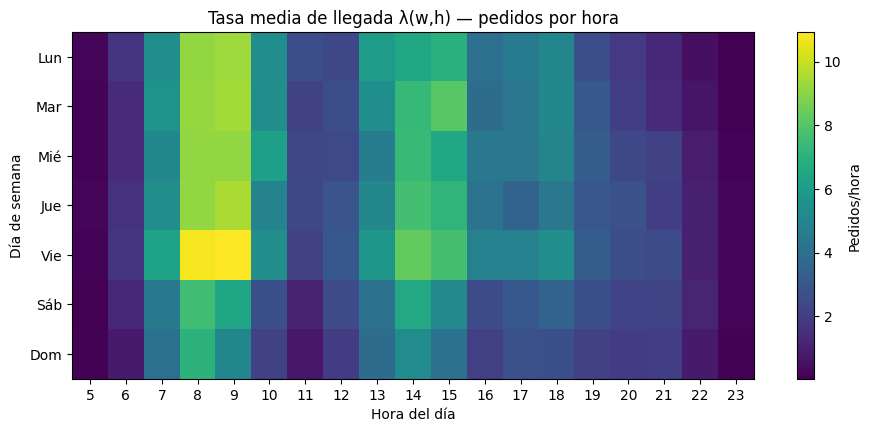

hora,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Lun,0.17,1.69,5.44,9.15,9.35,5.38,2.67,2.38,6.02,6.54,6.94,4.00,4.58,5.04,2.65,1.85,1.23,0.48,0.08
Mar,0.15,1.35,5.58,9.19,9.40,5.42,2.15,2.65,5.44,7.33,8.12,3.90,4.33,5.10,3.02,2.06,1.33,0.67,0.04
Mié,0.13,1.38,5.13,9.15,9.17,6.17,2.34,2.43,4.66,7.38,6.57,4.40,4.36,5.00,3.25,2.40,2.17,0.89,0.13
Jue,0.17,1.63,5.42,9.17,9.54,4.90,2.38,2.90,5.10,7.67,7.17,4.19,3.52,4.38,3.00,2.75,2.04,0.98,0.17
Vie,0.13,1.71,6.35,10.79,10.92,5.42,2.19,3.02,5.81,8.29,7.73,4.81,4.87,5.40,3.27,2.67,2.50,0.98,0.17
Sáb,0.06,1.23,4.44,7.58,6.48,2.71,1.13,2.52,4.10,6.60,5.17,2.58,3.04,3.50,2.69,2.21,2.29,1.15,0.17
Dom,0.12,0.85,4.00,7.06,5.02,2.15,0.73,1.96,3.90,5.31,4.15,2.10,2.75,2.69,2.19,1.94,2.08,0.81,0.12


In [39]:
# Tasas horarias históricas λ(w,h)
hourly_counts = (
    df.groupby(["dow", "hora"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=range(7), columns=hours, fill_value=0)
)
days_by_dow = pd.Series(calendar.weekday).value_counts().reindex(range(7)).sort_index()
rate_table = hourly_counts.div(days_by_dow.values, axis=0)
rate_table.index = DOW_NAMES

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(rate_table.values, aspect="auto")
ax.set_title("Tasa media de llegada λ(w,h) — pedidos por hora")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Día de semana")
ax.set_xticks(np.arange(len(hours)))
ax.set_xticklabels(hours)
ax.set_yticks(np.arange(7))
ax.set_yticklabels(DOW_NAMES)
fig.colorbar(im, ax=ax, label="Pedidos/hora")
plt.show()

display(rate_table.round(2))

## 4. Ajuste de conteos diarios: corrección del AIC

Se comparan cuatro especificaciones: Poisson única, binomial negativa única, Poisson por día de semana y binomial negativa por día de semana. La comparación usa

\[
AIC = 2k - 2\log L,
\]

donde \(k\) es el número de parámetros estimados. La corrección clave está en la binomial negativa por día de semana: debe estimarse con una log-verosimilitud numéricamente estable y con 14 parámetros, dos por cada día de semana.

La parametrización usada es \(\mu, \alpha\), con \(Var(Y)=\mu+\alpha\mu^2\). Cuando \(\alpha\to0\), la binomial negativa converge a Poisson. Para evitar errores de cancelación numérica cuando \(p\) está muy cerca de 1, la verosimilitud se evalúa con `log1p`.

In [40]:
def poisson_loglik(y, mu=None):
    y = np.asarray(y, dtype=float)
    if mu is None:
        mu = float(y.mean())
    return float(np.sum(stats.poisson.logpmf(y, mu)))


def nb_loglik_mu_alpha(y, mu, alpha):
    """Log-verosimilitud BN estable con media mu y sobredispersión alpha.

    Var(Y)=mu + alpha*mu^2. Si alpha≈0, se usa el límite Poisson.
    """
    y = np.asarray(y, dtype=float)
    if alpha < 1e-8:
        return poisson_loglik(y, mu)
    r = 1.0 / alpha
    log1p_alpha_mu = np.log1p(alpha * mu)
    log_alpha_mu = np.log(alpha * mu)
    ll = (
        special.gammaln(y + r)
        - special.gammaln(r)
        - special.gammaln(y + 1)
        - r * log1p_alpha_mu
        + y * (log_alpha_mu - log1p_alpha_mu)
    )
    return float(np.sum(ll))


def fit_nb_count(y):
    """Ajuste MLE de una binomial negativa para conteos.

    Devuelve el límite Poisson si no hay ganancia de verosimilitud sobre alpha=0.
    """
    y = np.asarray(y, dtype=float)
    mu0 = max(float(y.mean()), 1e-9)
    var0 = float(y.var(ddof=1)) if len(y) > 1 else mu0
    alpha_mom = max((var0 - mu0) / (mu0 ** 2), 1e-8)

    def nll(theta):
        mu = np.exp(theta[0])
        alpha = np.exp(theta[1])
        return -nb_loglik_mu_alpha(y, mu, alpha)

    starts = [alpha_mom, 1e-8, 1e-6, 1e-4, 1e-2, 1e-1, 1.0]
    best = None
    for a0 in starts:
        res = optimize.minimize(
            nll,
            x0=np.array([np.log(mu0), np.log(a0)]),
            method="L-BFGS-B",
            bounds=[(np.log(1e-6), np.log(1e6)), (np.log(1e-8), np.log(1e3))],
            options={"maxiter": 10000},
        )
        if best is None or res.fun < best.fun:
            best = res

    mu = float(np.exp(best.x[0]))
    alpha = float(np.exp(best.x[1]))
    ll_nb = -float(best.fun)

    ll_pois_boundary = poisson_loglik(y, mu0)
    if ll_pois_boundary >= ll_nb - 1e-6:
        return {"mu": mu0, "alpha": 0.0, "r": np.inf, "p": 1.0, "ll": ll_pois_boundary, "boundary": True}

    r = 1.0 / alpha
    p = r / (r + mu)
    return {"mu": mu, "alpha": alpha, "r": r, "p": p, "ll": ll_nb, "boundary": False}


def aic(loglik, k):
    return 2 * k - 2 * loglik

In [41]:
y_daily = daily_df["ordenes"].to_numpy()

# 1) Poisson única diaria
ll_pois_single = poisson_loglik(y_daily)

# 2) Binomial negativa única diaria
fit_nb_single = fit_nb_count(y_daily)
ll_nb_single = fit_nb_single["ll"]

# 3) Poisson por día de semana
ll_pois_weekday = sum(poisson_loglik(daily_df.loc[daily_df["dow"] == w, "ordenes"].to_numpy()) for w in range(7))

# 4) Binomial negativa por día de semana
nb_weekday_fits = {}
ll_nb_weekday = 0.0
for w in range(7):
    y_w = daily_df.loc[daily_df["dow"] == w, "ordenes"].to_numpy()
    fit_w = fit_nb_count(y_w)
    nb_weekday_fits[DOW_NAMES[w]] = fit_w
    ll_nb_weekday += fit_w["ll"]

model_comparison = pd.DataFrame([
    {"Modelo": "Poisson única diaria", "k": 1, "Log-verosimilitud": ll_pois_single, "AIC": aic(ll_pois_single, 1), "Lectura": "Ignora día de semana"},
    {"Modelo": "Binomial negativa única diaria", "k": 2, "Log-verosimilitud": ll_nb_single, "AIC": aic(ll_nb_single, 2), "Lectura": "Absorbe mezcla semanal como sobredispersión"},
    {"Modelo": "Poisson por día de semana", "k": 7, "Log-verosimilitud": ll_pois_weekday, "AIC": aic(ll_pois_weekday, 7), "Lectura": "Modelo seleccionado"},
    {"Modelo": "Binomial negativa por día de semana", "k": 14, "Log-verosimilitud": ll_nb_weekday, "AIC": aic(ll_nb_weekday, 14), "Lectura": "Mejor log L, pero penalizada por 7 parámetros extra"},
])

display(model_comparison.round({"Log-verosimilitud": 1, "AIC": 1}))

delta_ll = ll_nb_weekday - ll_pois_weekday
delta_aic = aic(ll_nb_weekday, 14) - aic(ll_pois_weekday, 7)
print(f"Mejora de log-verosimilitud de BN por día vs Poisson por día: {delta_ll:.3f}")
print(f"Cambio de AIC al pasar de Poisson por día a BN por día: {delta_aic:+.3f}")
print("Interpretación: la mejora de ajuste no compensa la penalización de 7 parámetros extra; se conserva Poisson por día de semana.")

,Modelo,k,Log-verosimilitud,AIC,Lectura
0,Poisson única diaria,1,-1670.2,3342.5,Ignora día de semana
1,Binomial negativa única diaria,2,-1503.7,3011.3,Absorbe mezcla semanal como sobredispersión
2,Poisson por día de semana,7,-1304.9,2623.8,Modelo seleccionado
3,Binomial negativa por día de semana,14,-1303.6,2635.2,"Mejor log L, pero penalizada por 7 parámetros ..."


Mejora de log-verosimilitud de BN por día vs Poisson por día: 1.270
Cambio de AIC al pasar de Poisson por día a BN por día: +11.460
Interpretación: la mejora de ajuste no compensa la penalización de 7 parámetros extra; se conserva Poisson por día de semana.


## 5. Diagnósticos del supuesto de Poisson condicionado

La selección por AIC se complementa con pruebas de dispersión, bondad de ajuste, autocorrelación residual, estacionalidad mensual residual e interarribos. La idea central es separar la sobredispersión real de la sobredispersión aparente causada por mezclar días con niveles de demanda distintos.

In [42]:
def poisson_gof_grouped(y, lam=None, min_expected=5):
    """Prueba χ² de bondad de ajuste Poisson con agrupamiento de bins para esperados mínimos."""
    y = np.asarray(y, dtype=int)
    n = len(y)
    if lam is None:
        lam = float(y.mean())

    hi = max(int(y.max()) + 20, int(stats.poisson.ppf(0.999999, lam)) + 5)
    ks = np.arange(0, hi + 1)
    probs = stats.poisson.pmf(ks, lam)
    probs[-1] += max(0.0, 1.0 - probs.sum())  # cola numérica
    obs_counts = np.bincount(np.minimum(y, hi), minlength=hi + 1)
    exp_counts = n * probs

    bins = []
    obs_acc = 0.0
    exp_acc = 0.0
    start = 0
    for k in range(hi + 1):
        obs_acc += obs_counts[k]
        exp_acc += exp_counts[k]
        if exp_acc >= min_expected:
            bins.append((start, k, obs_acc, exp_acc))
            start = k + 1
            obs_acc = 0.0
            exp_acc = 0.0
    if exp_acc > 1e-12:
        if bins:
            a, b, o, e = bins[-1]
            bins[-1] = (a, hi, o + obs_acc, e + exp_acc)
        else:
            bins.append((start, hi, obs_acc, exp_acc))

    obs = np.array([b[2] for b in bins], dtype=float)
    exp = np.array([b[3] for b in bins], dtype=float)
    exp *= obs.sum() / exp.sum()
    chi2 = float(((obs - exp) ** 2 / exp).sum())
    dof = max(len(bins) - 1 - 1, 1)  # resta 1 parámetro estimado: lambda
    p_value = float(1 - stats.chi2.cdf(chi2, dof))
    return chi2, dof, p_value, len(bins)


diag_rows = []
for w in range(7):
    y_w = daily_df.loc[daily_df["dow"] == w, "ordenes"].to_numpy()
    chi2, dof, p_value, n_bins = poisson_gof_grouped(y_w)
    diag_rows.append({
        "Día": DOW_NAMES[w],
        "N días": len(y_w),
        "Media": y_w.mean(),
        "Varianza": y_w.var(ddof=1),
        "Índice dispersión var/media": y_w.var(ddof=1) / y_w.mean(),
        "χ²": chi2,
        "gl": dof,
        "p-valor GOF Poisson": p_value,
        "bins agrupados": n_bins,
    })

dispersion_gof = pd.DataFrame(diag_rows)
display(dispersion_gof.round(3))

,Día,N días,Media,Varianza,Índice dispersión var/media,χ²,gl,p-valor GOF Poisson,bins agrupados
0,Lun,52,75.654,92.858,1.227,8.308,6,0.216,8
1,Mar,52,77.231,74.652,0.967,3.749,6,0.711,8
2,Mié,53,77.094,90.933,1.180,3.691,6,0.718,8
3,Jue,52,77.115,60.967,0.791,6.660,6,0.353,8
4,Vie,52,87.038,94.783,1.089,4.696,7,0.697,9
5,Sáb,52,59.654,63.799,1.069,9.392,7,0.226,9
6,Dom,52,49.923,60.308,1.208,9.832,7,0.198,9


ANOVA de mes sobre residuos diarios: F=0.673, p=0.764
KS uniformidad intra-hora: D=0.0059, p=0.318
KS exponencialidad interarribos viernes 8–10 h: D=0.0089, p=1.000, media=5.23 min


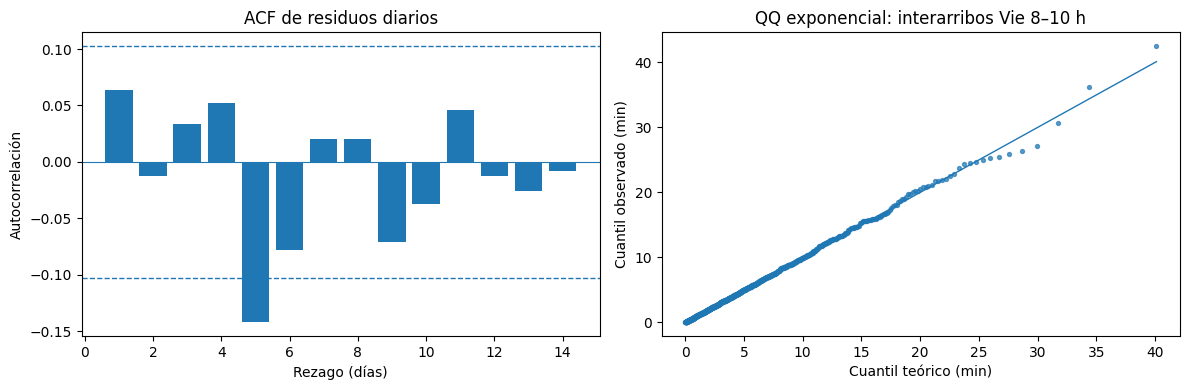

In [43]:
# Residuos tras remover el efecto del día de semana
lambda_by_weekday = daily_df.groupby("dow")["ordenes"].mean()
daily_df["lambda_weekday"] = daily_df["dow"].map(lambda_by_weekday)
daily_df["resid"] = daily_df["ordenes"] - daily_df["lambda_weekday"]
daily_df["pearson_resid"] = daily_df["resid"] / np.sqrt(daily_df["lambda_weekday"])

# ANOVA de mes sobre residuos no escalados
anova_month = stats.f_oneway(*[g["resid"].to_numpy() for _, g in daily_df.groupby("mes")])
print(f"ANOVA de mes sobre residuos diarios: F={anova_month.statistic:.3f}, p={anova_month.pvalue:.3f}")

# ACF manual de residuos de Pearson
def autocorr(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:-lag], x[lag:]) / denom for lag in range(1, max_lag + 1)])

max_lag = 14
acf_vals = autocorr(daily_df["pearson_resid"].to_numpy(), max_lag=max_lag)
conf = 1.96 / np.sqrt(len(daily_df))

# Uniformidad intra-hora
minute_fraction = (df["fecha_hora_llegada"].dt.minute + df["fecha_hora_llegada"].dt.second / 60.0) / 60.0
ks_uniform = stats.kstest(minute_fraction, "uniform")
print(f"KS uniformidad intra-hora: D={ks_uniform.statistic:.4f}, p={ks_uniform.pvalue:.3f}")

# Interarribos dentro de un bloque estable: viernes 8:00-10:00
block = df[(df["dow"] == 4) & (df["hora"] >= 8) & (df["hora"] < 10)].sort_values("fecha_hora_llegada")
intervals = []
for _, g in block.groupby("fecha"):
    delta_min = g["fecha_hora_llegada"].sort_values().diff().dropna().dt.total_seconds() / 60.0
    intervals.extend(delta_min.tolist())
intervals = np.asarray(intervals, dtype=float)
ks_expon = stats.kstest(intervals, "expon", args=(0, intervals.mean()))
print(f"KS exponencialidad interarribos viernes 8–10 h: D={ks_expon.statistic:.4f}, p={ks_expon.pvalue:.3f}, media={intervals.mean():.2f} min")

# Figuras: ACF y QQ exponencial
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, max_lag + 1), acf_vals)
axes[0].axhline(conf, linestyle="--", linewidth=1)
axes[0].axhline(-conf, linestyle="--", linewidth=1)
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("ACF de residuos diarios")
axes[0].set_xlabel("Rezago (días)")
axes[0].set_ylabel("Autocorrelación")

intervals_sorted = np.sort(intervals)
prob = (np.arange(1, len(intervals_sorted) + 1) - 0.5) / len(intervals_sorted)
theoretical = stats.expon.ppf(prob, scale=intervals.mean())
axes[1].scatter(theoretical, intervals_sorted, s=8, alpha=0.7)
axes[1].plot([0, theoretical.max()], [0, theoretical.max()], linewidth=1)
axes[1].set_title("QQ exponencial: interarribos Vie 8–10 h")
axes[1].set_xlabel("Cuantil teórico (min)")
axes[1].set_ylabel("Cuantil observado (min)")
plt.tight_layout()
plt.show()

## 6. Atributos de la orden

La frecuencia de llegada no basta para simular carga de trabajo: hay que asignar segmento, tipo de servicio, cantidad de bolsas y composición. Las pruebas siguientes justifican una estructura parsimoniosa: segmento condicionado por día/hora, servicio condicionado por segmento, y bolsas condicionadas por segmento×servicio.

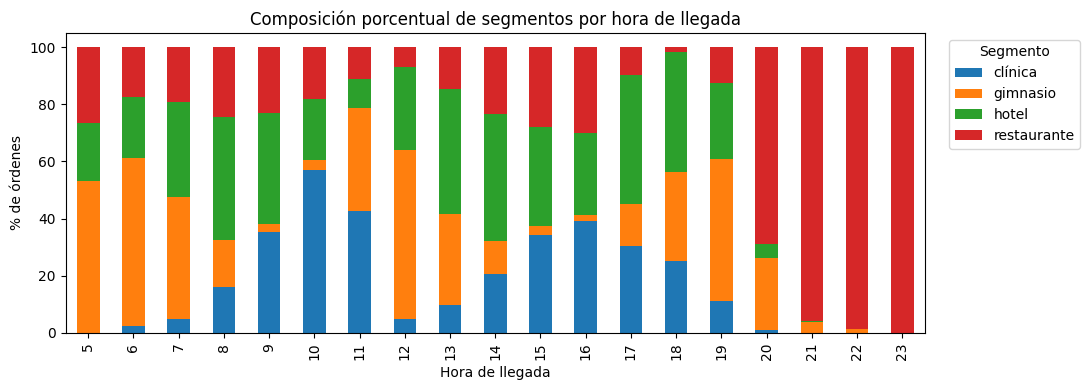

Ejemplo de P(S | día, hora) con suavizamiento de Laplace: viernes 8:00 y 21:00


,Vie 08,Vie 21
segmento_cliente,,
clínica,0.143,0.007
gimnasio,0.188,0.015
hotel,0.423,0.015
restaurante,0.246,0.963


In [44]:
# Composición de segmentos por hora agregada
seg_by_hour = pd.crosstab(df["hora"], df["segmento_cliente"], normalize="index").reindex(columns=segments) * 100
ax = seg_by_hour.plot(kind="bar", stacked=True, figsize=(11, 4))
ax.set_title("Composición porcentual de segmentos por hora de llegada")
ax.set_xlabel("Hora de llegada")
ax.set_ylabel("% de órdenes")
ax.legend(title="Segmento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Probabilidades P(S | día, hora) con suavizamiento de Laplace
multi_index = pd.MultiIndex.from_product([range(7), hours], names=["dow", "hora"])
seg_counts = (
    df.groupby(["dow", "hora", "segmento_cliente"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=multi_index, columns=segments, fill_value=0)
)
seg_probs = ((seg_counts + 1).T / (seg_counts.sum(axis=1) + len(segments))).T

print("Ejemplo de P(S | día, hora) con suavizamiento de Laplace: viernes 8:00 y 21:00")
display(pd.DataFrame({
    "Vie 08": seg_probs.loc[(4, 8), segments],
    "Vie 21": seg_probs.loc[(4, 21), segments],
}).round(3))

In [45]:
# Tipo de servicio: Bernoulli condicionada al segmento
p_fast_by_segment = (
    df.groupby("segmento_cliente")["tipo_servicio"]
      .apply(lambda s: (int((s == "rápido").sum()) + 1) / (len(s) + 2))
      .reindex(segments)
)

service_tests = []
for seg in segments:
    g = df[df["segmento_cliente"] == seg]
    tab = pd.crosstab(g["hora"], g["tipo_servicio"]).reindex(columns=services, fill_value=0)
    chi2, p_value, dof, expected = stats.chi2_contingency(tab)
    service_tests.append({
        "Segmento": seg,
        "P(rápido | segmento) suavizada": p_fast_by_segment.loc[seg],
        "χ² hora×servicio": chi2,
        "gl": dof,
        "p-valor": p_value,
    })

service_tests = pd.DataFrame(service_tests)
display(service_tests.round(4))
print("Lectura: p-valores altos; dentro de cada segmento no hay evidencia fuerte para añadir dependencia horaria al servicio rápido.")

,Segmento,P(rápido | segmento) suavizada,χ² hora×servicio,gl,p-valor
0,clínica,0.1523,12.0993,14,0.5983
1,gimnasio,0.1087,24.0796,17,0.1173
2,hotel,0.0519,16.5103,16,0.4179
3,restaurante,0.2088,19.3697,18,0.3694


Lectura: p-valores altos; dentro de cada segmento no hay evidencia fuerte para añadir dependencia horaria al servicio rápido.


In [46]:
# Independencia del tamaño de orden respecto a la hora, condicionando por segmento×servicio
kw_rows = []
for (seg, service), g in df.groupby(["segmento_cliente", "tipo_servicio"]):
    hour_groups = [x["bolsas_total"].to_numpy() for _, x in g.groupby("hora") if len(x) > 0]
    stat, p_value = stats.kruskal(*hour_groups)
    kw_rows.append({
        "Segmento": seg,
        "Servicio": service,
        "N": len(g),
        "Horas con datos": len(hour_groups),
        "Kruskal-Wallis H": stat,
        "p-valor": p_value,
    })

kw_table = pd.DataFrame(kw_rows).sort_values(["Segmento", "Servicio"])
display(kw_table.round(4))
print("Lectura: dentro de las 8 celdas segmento×servicio, el tamaño de orden no muestra dependencia horaria relevante.")

,Segmento,Servicio,N,Horas con datos,Kruskal-Wallis H,p-valor
0,clínica,normal,5142,15,11.8048,0.6220
1,clínica,rápido,923,15,8.2210,0.8775
2,gimnasio,normal,4527,18,20.3350,0.2575
3,gimnasio,rápido,551,18,18.4310,0.3621
4,hotel,normal,8391,17,13.8049,0.6132
5,hotel,rápido,458,15,9.9056,0.7690
6,restaurante,normal,4968,19,12.4362,0.8239
7,restaurante,rápido,1310,18,12.1578,0.7905


Lectura: dentro de las 8 celdas segmento×servicio, el tamaño de orden no muestra dependencia horaria relevante.


## 7. Bolsas totales por orden

Todas las órdenes tienen al menos una bolsa. Por eso se ajustan distribuciones desplazadas: si \(Y\) es el conteo modelado, entonces

\[
K = 1 + Y,
\]

con \(K\) = `bolsas_total`. La comparación por celda segmento×servicio evita mezclar órdenes de perfiles operativos distintos.

In [47]:
# Estadísticos descriptivos de bolsas
bag_cols = ["bolsas_delicada", "bolsas_color", "bolsas_blanca", "bolsas_total"]
bag_desc = df[bag_cols].agg(["mean", "std", "min", "median", lambda s: s.quantile(0.75), lambda s: s.quantile(0.90), lambda s: s.quantile(0.95), lambda s: s.quantile(0.99), "max"]).T
bag_desc.columns = ["Media", "Desv. est.", "Mín.", "P50", "P75", "P90", "P95", "P99", "Máx."]
display(bag_desc.round(2))

volume_mix = 100 * df[["bolsas_delicada", "bolsas_color", "bolsas_blanca"]].sum() / df["bolsas_total"].sum()
print("Mix agregado de volumen (%):")
display(volume_mix.rename({"bolsas_delicada": "delicada", "bolsas_color": "color", "bolsas_blanca": "blanca"}).round(2))

,Media,Desv. est.,Mín.,P50,P75,P90,P95,P99,Máx.
bolsas_delicada,0.15,0.54,0.0,0.0,0.0,1.0,1.0,2.0,26.0
bolsas_color,1.00,1.58,0.0,0.0,1.0,3.0,4.0,7.0,26.0
bolsas_blanca,3.56,3.62,0.0,3.0,5.0,8.0,10.0,17.0,48.0
bolsas_total,4.71,3.51,1.0,4.0,6.0,9.0,11.0,18.0,48.0


Mix agregado de volumen (%):


,0
delicada,3.16
color,21.30
blanca,75.54


In [48]:
def fit_shifted_bag_model(k_values):
    """Ajusta 1+Poisson y 1+BN a bolsas_total y selecciona por AIC."""
    k_values = np.asarray(k_values, dtype=int)
    y = k_values - 1
    lam = float(y.mean())
    ll_poisson = poisson_loglik(y, lam)
    aic_poisson = aic(ll_poisson, 1)

    nb_fit = fit_nb_count(y)
    ll_nb = nb_fit["ll"]
    aic_nb = aic(ll_nb, 2)

    if aic_poisson <= aic_nb:
        selected = "1 + Poisson"
    else:
        selected = "1 + Bin. negativa"

    return {
        "lambda": lam,
        "ll_poisson": ll_poisson,
        "aic_poisson": aic_poisson,
        "r": nb_fit["r"],
        "p": nb_fit["p"],
        "alpha": nb_fit["alpha"],
        "ll_nb": ll_nb,
        "aic_nb": aic_nb,
        "seleccion": selected,
    }

bag_fit_rows = []
bag_models = {}
for (seg, service), g in df.groupby(["segmento_cliente", "tipo_servicio"]):
    fit = fit_shifted_bag_model(g["bolsas_total"].to_numpy())
    if fit["seleccion"] == "1 + Poisson":
        bag_models[(seg, service)] = {"dist": "poisson", "lambda": fit["lambda"]}
        aic_sel = fit["aic_poisson"]
    else:
        bag_models[(seg, service)] = {"dist": "nbinom", "r": fit["r"], "p": fit["p"]}
        aic_sel = fit["aic_nb"]
    bag_fit_rows.append({
        "Segmento": seg,
        "Servicio": service,
        "N": len(g),
        "Media K": g["bolsas_total"].mean(),
        "Desv. K": g["bolsas_total"].std(ddof=1),
        "Distribución": fit["seleccion"],
        "λ Poisson": fit["lambda"] if fit["seleccion"] == "1 + Poisson" else np.nan,
        "r BN": fit["r"] if fit["seleccion"] == "1 + Bin. negativa" else np.nan,
        "p BN": fit["p"] if fit["seleccion"] == "1 + Bin. negativa" else np.nan,
        "AIC seleccionado": aic_sel,
        "AIC 1+Poisson": fit["aic_poisson"],
        "AIC 1+BN": fit["aic_nb"],
    })

bag_fit_table = pd.DataFrame(bag_fit_rows).sort_values(["Segmento", "Servicio"])
display(bag_fit_table.round(3))

,Segmento,Servicio,N,Media K,Desv. K,Distribución,λ Poisson,r BN,p BN,AIC seleccionado,AIC 1+Poisson,AIC 1+BN
0,clínica,normal,5142,5.071,2.952,1 + Bin. negativa,NaN,5.052,0.554,23665.047,25023.484,23665.047
1,clínica,rápido,923,3.107,1.715,1 + Bin. negativa,NaN,8.410,0.800,3278.178,3312.124,3278.178
2,gimnasio,normal,4527,3.945,2.349,1 + Bin. negativa,NaN,4.731,0.616,18748.728,19521.154,18748.728
3,gimnasio,rápido,551,2.655,1.425,1 + Bin. negativa,NaN,11.761,0.877,1771.467,1776.931,1771.467
4,hotel,normal,8391,6.757,4.365,1 + Bin. negativa,NaN,3.414,0.372,44526.834,51328.598,44526.834
5,hotel,rápido,458,4.087,2.490,1 + Bin. negativa,NaN,4.120,0.572,1949.670,2051.348,1949.670
6,restaurante,normal,4968,2.889,1.813,1 + Bin. negativa,NaN,4.091,0.684,17512.844,18066.606,17512.844
7,restaurante,rápido,1310,1.981,0.920,1 + Poisson,0.981,NaN,NaN,3251.337,3251.337,3253.337


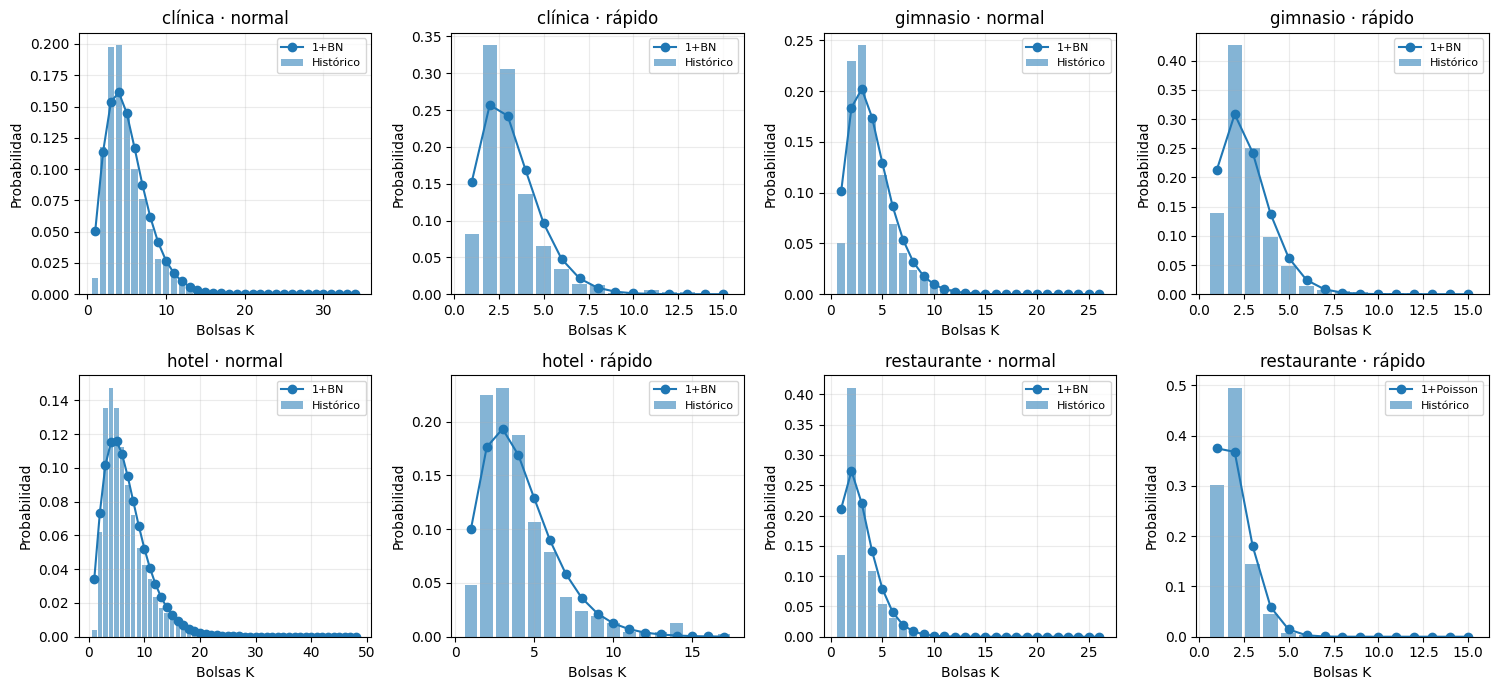

In [49]:
# Gráfica de ajuste por celda: histograma histórico vs pmf seleccionada
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=False)
axes = axes.ravel()

for ax, ((seg, service), g) in zip(axes, df.groupby(["segmento_cliente", "tipo_servicio"], sort=True)):
    k_obs = g["bolsas_total"].to_numpy()
    max_k = max(k_obs.max(), 15)
    ks = np.arange(1, max_k + 1)
    hist_counts = np.bincount(k_obs, minlength=max_k + 1)[1:]
    hist_prob = hist_counts / hist_counts.sum()

    model = bag_models[(seg, service)]
    if model["dist"] == "poisson":
        pmf = stats.poisson.pmf(ks - 1, model["lambda"])
        label = "1+Poisson"
    else:
        pmf = stats.nbinom.pmf(ks - 1, model["r"], model["p"])
        label = "1+BN"

    ax.bar(ks, hist_prob, alpha=0.55, label="Histórico")
    ax.plot(ks, pmf, marker="o", linewidth=1.5, label=label)
    ax.set_title(f"{seg} · {service}")
    ax.set_xlabel("Bolsas K")
    ax.set_ylabel("Probabilidad")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Composición de bolsas: delicada, color y blanca

Después de simular el total \(K\), la composición debe respetar exactamente

\[
D + C + B = K.
\]

La multinomial simple preserva la suma, pero suele subestimar la variabilidad entre órdenes. La Dirichlet-multinomial agrega heterogeneidad entre órdenes mediante una concentración \(\alpha_0\). En este notebook se fija la media de la Dirichlet en las proporciones empíricas de cada celda y se estima solo \(\alpha_0\) por máxima verosimilitud. Esto reproduce la metodología corregida y evita sobreparametrizar la composición.

In [50]:
COMP_COLS = ["bolsas_delicada", "bolsas_color", "bolsas_blanca"]

def multinomial_loglik(X, p):
    X = np.asarray(X, dtype=float)
    p = np.asarray(p, dtype=float)
    K = X.sum(axis=1)
    return float(np.sum(special.gammaln(K + 1) - special.gammaln(X + 1).sum(axis=1) + X @ np.log(p)))


def dirichlet_multinomial_loglik_fixed_mean(X, p, alpha0):
    X = np.asarray(X, dtype=float)
    p = np.asarray(p, dtype=float)
    alpha = p * alpha0
    K = X.sum(axis=1)
    ll = (
        special.gammaln(K + 1)
        - special.gammaln(X + 1).sum(axis=1)
        + special.gammaln(alpha0)
        - special.gammaln(K + alpha0)
        + (special.gammaln(X + alpha) - special.gammaln(alpha)).sum(axis=1)
    )
    return float(np.sum(ll))


def fit_dirichlet_multinomial_fixed_mean(X):
    X = np.asarray(X, dtype=float)
    totals = X.sum(axis=0)
    p = totals / totals.sum()
    ll_mult = multinomial_loglik(X, p)

    def nll(log_alpha0):
        return -dirichlet_multinomial_loglik_fixed_mean(X, p, float(np.exp(log_alpha0[0])))

    starts = [0.1, 0.3, 0.5, 1, 2, 5, 10, 30, 100, 300, 1000, 1e4, 1e5, 1e6]
    best = None
    for a0 in starts:
        res = optimize.minimize(
            nll,
            x0=np.array([np.log(a0)]),
            method="L-BFGS-B",
            bounds=[(np.log(1e-6), np.log(1e9))],
            options={"maxiter": 5000},
        )
        if best is None or res.fun < best.fun:
            best = res

    alpha0 = float(np.exp(best.x[0]))
    ll_dm = -float(best.fun)
    # Multinomial: 2 parámetros de proporciones. DM: 2 proporciones + 1 concentración.
    delta_aic_vs_mult = (2 * 2 - 2 * ll_mult) - (2 * 3 - 2 * ll_dm)
    use_dm = (delta_aic_vs_mult > 0) and (alpha0 < 1e6)
    return {
        "p": p,
        "alpha0": alpha0,
        "alpha": p * alpha0,
        "ll_mult": ll_mult,
        "ll_dm": ll_dm,
        "delta_aic_vs_mult": delta_aic_vs_mult,
        "seleccion": "Dirichlet-multinomial" if use_dm else "Multinomial",
    }

comp_rows = []
comp_models = {}
for (seg, service), g in df.groupby(["segmento_cliente", "tipo_servicio"]):
    fit = fit_dirichlet_multinomial_fixed_mean(g[COMP_COLS].to_numpy())
    comp_models[(seg, service)] = {
        "dist": "dirichlet-multinomial" if fit["seleccion"] == "Dirichlet-multinomial" else "multinomial",
        "p": fit["p"],
        "alpha": fit["alpha"],
        "alpha0": fit["alpha0"],
        "delta_aic": fit["delta_aic_vs_mult"],
    }
    alpha_display = fit["alpha"] if fit["seleccion"] == "Dirichlet-multinomial" else np.array([np.nan, np.nan, np.nan])
    comp_rows.append({
        "Segmento": seg,
        "Servicio": service,
        "P(del.)": fit["p"][0],
        "P(color)": fit["p"][1],
        "P(blanca)": fit["p"][2],
        "α del.": alpha_display[0],
        "α color": alpha_display[1],
        "α blanca": alpha_display[2],
        "α0": fit["alpha0"] if fit["seleccion"] == "Dirichlet-multinomial" else np.inf,
        "∆AIC vs multinomial": fit["delta_aic_vs_mult"],
        "Distribución": fit["seleccion"],
    })

comp_fit_table = pd.DataFrame(comp_rows).sort_values(["Segmento", "Servicio"])
display(comp_fit_table.round(3))
print("∆AIC positivo indica mejora de la Dirichlet-multinomial. Restaurante·rápido queda en el límite multinomial y se simula como multinomial simple.")

,Segmento,Servicio,P(del.),P(color),P(blanca),α del.,α color,α blanca,α0,∆AIC vs multinomial,Distribución
0,clínica,normal,0.028,0.155,0.817,0.091,0.503,2.655,3.249,2772.637,Dirichlet-multinomial
1,clínica,rápido,0.050,0.178,0.772,0.353,1.260,5.473,7.087,99.295,Dirichlet-multinomial
2,gimnasio,normal,0.058,0.603,0.339,0.095,0.991,0.557,1.642,4435.452,Dirichlet-multinomial
3,gimnasio,rápido,0.060,0.578,0.362,0.245,2.354,1.472,4.072,86.986,Dirichlet-multinomial
4,hotel,normal,0.018,0.060,0.922,0.145,0.472,7.310,7.927,2368.348,Dirichlet-multinomial
5,hotel,rápido,0.027,0.073,0.900,0.899,2.464,30.301,33.664,3.124,Dirichlet-multinomial
6,restaurante,normal,0.045,0.390,0.564,0.150,1.291,1.867,3.308,1365.278,Dirichlet-multinomial
7,restaurante,rápido,0.066,0.418,0.516,NaN,NaN,NaN,inf,-2.000,Multinomial


∆AIC positivo indica mejora de la Dirichlet-multinomial. Restaurante·rápido queda en el límite multinomial y se simula como multinomial simple.


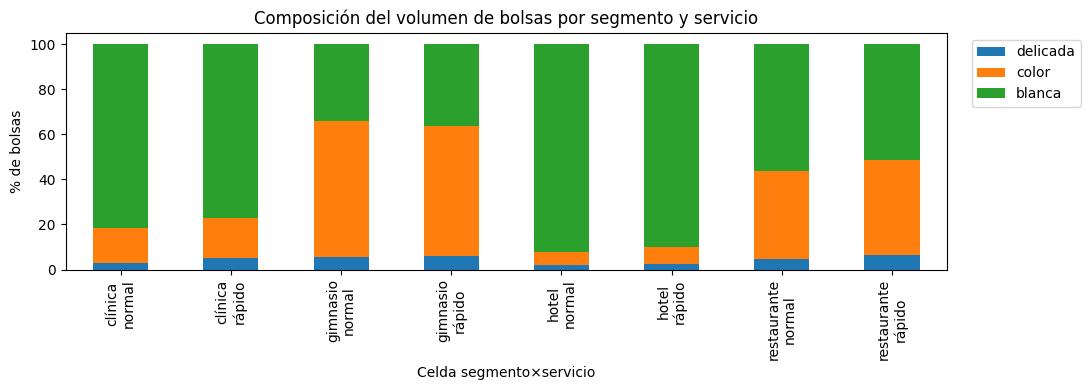

In [51]:
# Composición del volumen por celda
mix_cell = (
    df.groupby(["segmento_cliente", "tipo_servicio"])[COMP_COLS]
      .sum()
)
mix_cell_pct = 100 * mix_cell.div(mix_cell.sum(axis=1), axis=0)
mix_cell_pct.index = [f"{a}\n{b}" for a, b in mix_cell_pct.index]

ax = mix_cell_pct.plot(kind="bar", stacked=True, figsize=(11, 4))
ax.set_title("Composición del volumen de bolsas por segmento y servicio")
ax.set_ylabel("% de bolsas")
ax.set_xlabel("Celda segmento×servicio")
ax.legend(["delicada", "color", "blanca"], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Generador completo de demanda

El generador simula eventos de llegada y atributos de orden con esta secuencia:

1. Para cada fecha, identificar día de semana.
2. Para cada hora operativa, generar \(N(d,h) \sim Poisson(\lambda(w,h))\).
3. Asignar timestamp uniforme dentro de la hora.
4. Asignar segmento con \(P(S\mid w,h)\) suavizada por Laplace.
5. Asignar servicio rápido con Bernoulli \(P(T=rápido\mid S)\).
6. Generar bolsas totales \(K\) según la distribución desplazada de la celda segmento×servicio.
7. Generar composición \((D,C,B)\) con Dirichlet-multinomial o multinomial según la celda.

La implementación de validación es vectorizada: simula órdenes completas, pero evita ciclos innecesarios por evento.

In [52]:
# Preparación de arrays para simulación rápida
lambda_wh = rate_table.to_numpy()  # shape: 7 × horas
seg_prob_array = np.zeros((7, len(hours), len(segments)))
for w in range(7):
    for j, h in enumerate(hours):
        seg_prob_array[w, j, :] = seg_probs.loc[(w, h), segments].to_numpy(dtype=float)

p_fast_base = p_fast_by_segment.to_numpy(dtype=float)
key_order = [(seg, service) for seg in segments for service in services]
bag_by_gid = [bag_models[k] for k in key_order]
comp_by_gid = [comp_models[k] for k in key_order]
hotel_idx = int(np.where(segments == "hotel")[0][0])

def simulate_laundry_year(
    seed=RNG_SEED,
    start="2025-01-01",
    end="2025-12-31",
    rate_scale=1.0,
    fast_multiplier=1.0,
    return_events=False,
):
    """Simula un año de demanda.

    Parámetros interactivos principales:
    - rate_scale: multiplica todas las tasas de llegada λ(w,h). Ej.: 1.10 = +10% demanda.
    - fast_multiplier: multiplica P(servicio rápido | segmento), truncado a 0.95.
    - return_events: si True, devuelve un DataFrame de órdenes simuladas.
    """
    rng_local = np.random.default_rng(seed)
    sim_dates = pd.date_range(start, end, freq="D")
    dow = sim_dates.weekday.to_numpy()

    lam = lambda_wh[dow, :] * rate_scale
    counts_by_cell = rng_local.poisson(lam)  # días × horas
    daily_counts = counts_by_cell.sum(axis=1)

    flat_counts = counts_by_cell.ravel()
    n_orders = int(flat_counts.sum())
    if n_orders == 0:
        empty_metrics = {
            "orders": 0, "bags": 0, "fast": 0, "hotel": 0,
            "del": 0, "color": 0, "white": 0,
            "daily_mean": 0.0, "daily_std": 0.0,
        }
        if return_events:
            return pd.DataFrame(), empty_metrics
        return empty_metrics

    n_hours = len(hours)
    cell_ids = np.repeat(np.arange(flat_counts.size), flat_counts)
    day_ix = cell_ids // n_hours
    hour_ix = cell_ids % n_hours

    # Segmento: categórica dependiente de día/hora con Laplace.
    probs = seg_prob_array[dow[day_ix], hour_ix, :]
    cum_probs = np.cumsum(probs, axis=1)
    u = rng_local.random(n_orders)
    seg_idx = (u[:, None] > cum_probs[:, :-1]).sum(axis=1)

    # Servicio: Bernoulli dependiente de segmento.
    p_fast = np.clip(p_fast_base * fast_multiplier, 0.0, 0.95)
    fast = rng_local.random(n_orders) < p_fast[seg_idx]
    service_idx = fast.astype(int)  # 0 normal, 1 rápido
    group_idx = seg_idx * len(services) + service_idx

    # Bolsas totales y composición.
    K = np.empty(n_orders, dtype=np.int16)
    D = np.empty(n_orders, dtype=np.int16)
    C = np.empty(n_orders, dtype=np.int16)
    B = np.empty(n_orders, dtype=np.int16)

    for gid, key in enumerate(key_order):
        idx = np.flatnonzero(group_idx == gid)
        m = idx.size
        if m == 0:
            continue

        bag_model = bag_by_gid[gid]
        if bag_model["dist"] == "poisson":
            k_vals = 1 + rng_local.poisson(bag_model["lambda"], size=m)
        else:
            k_vals = 1 + rng_local.negative_binomial(bag_model["r"], bag_model["p"], size=m)
        K[idx] = k_vals

        comp_model = comp_by_gid[gid]
        if comp_model["dist"] == "dirichlet-multinomial":
            p_orders = rng_local.dirichlet(comp_model["alpha"], size=m)
        else:
            p_orders = np.broadcast_to(comp_model["p"], (m, 3))

        d_vals = rng_local.binomial(k_vals, p_orders[:, 0])
        remaining = k_vals - d_vals
        p_color_cond = p_orders[:, 1] / (1 - p_orders[:, 0])
        c_vals = rng_local.binomial(remaining, p_color_cond)
        b_vals = remaining - c_vals

        D[idx] = d_vals
        C[idx] = c_vals
        B[idx] = b_vals

    metrics = {
        "orders": n_orders,
        "bags": int(K.sum()),
        "fast": int(fast.sum()),
        "hotel": int((seg_idx == hotel_idx).sum()),
        "del": int(D.sum()),
        "color": int(C.sum()),
        "white": int(B.sum()),
        "daily_mean": float(daily_counts.mean()),
        "daily_std": float(daily_counts.std(ddof=1)),
    }

    if return_events:
        seconds = rng_local.random(n_orders) * 3600
        timestamps = (
            sim_dates.values[day_ix]
            + (hours[hour_ix] * 3600 * 10**9).astype("timedelta64[ns]")
            + (seconds * 10**9).astype("timedelta64[ns]")
        )
        events = pd.DataFrame({
            "fecha_hora_llegada": pd.to_datetime(timestamps),
            "segmento_cliente": segments[seg_idx],
            "tipo_servicio": services[service_idx],
            "bolsas_delicada": D,
            "bolsas_color": C,
            "bolsas_blanca": B,
            "bolsas_total": K,
        }).sort_values("fecha_hora_llegada").reset_index(drop=True)
        events.insert(0, "id_orden_sim", [f"SIM-{i+1:06d}" for i in range(len(events))])
        return events, metrics

    return metrics


def demand_metrics_table(m):
    orders = max(m["orders"], 1)
    bags = max(m["bags"], 1)
    return {
        "Órdenes anuales": m["orders"],
        "Pedidos/día promedio": m["daily_mean"],
        "Pedidos/día desv. est.": m["daily_std"],
        "Bolsas anuales": m["bags"],
        "Bolsas por orden": m["bags"] / orders,
        "% servicio rápido": 100 * m["fast"] / orders,
        "% hotel": 100 * m["hotel"] / orders,
        "% delicada": 100 * m["del"] / bags,
        "% color": 100 * m["color"] / bags,
        "% blanca": 100 * m["white"] / bags,
    }


def observed_metrics():
    return {
        "orders": len(df),
        "bags": int(df["bolsas_total"].sum()),
        "fast": int((df["tipo_servicio"] == "rápido").sum()),
        "hotel": int((df["segmento_cliente"] == "hotel").sum()),
        "del": int(df["bolsas_delicada"].sum()),
        "color": int(df["bolsas_color"].sum()),
        "white": int(df["bolsas_blanca"].sum()),
        "daily_mean": float(daily_orders.mean()),
        "daily_std": float(daily_orders.std(ddof=1)),
    }

# Una réplica para inspección
sim_events, sim_metrics = simulate_laundry_year(seed=RNG_SEED, return_events=True)
print(f"Órdenes simuladas en una réplica: {len(sim_events):,}")
display(sim_events.head())
display(pd.Series(demand_metrics_table(sim_metrics)).to_frame("Réplica simulada").round(3))

Órdenes simuladas en una réplica: 26,232


,id_orden_sim,fecha_hora_llegada,segmento_cliente,tipo_servicio,bolsas_delicada,bolsas_color,bolsas_blanca,bolsas_total
0,SIM-000001,2025-01-01 05:14:04.302484398,restaurante,normal,0,2,0,2
1,SIM-000002,2025-01-01 07:09:31.496099572,restaurante,normal,0,0,1,1
2,SIM-000003,2025-01-01 07:18:58.120291037,hotel,normal,0,0,6,6
3,SIM-000004,2025-01-01 07:24:53.133084910,restaurante,normal,0,1,0,1
4,SIM-000005,2025-01-01 07:42:48.533005561,hotel,normal,0,0,4,4


,Réplica simulada
Órdenes anuales,26232.000
Pedidos/día promedio,71.868
Pedidos/día desv. est.,14.301
Bolsas anuales,124082.000
Bolsas por orden,4.730
% servicio rápido,12.656
% hotel,33.547
% delicada,3.230
% color,20.970
% blanca,75.800


## 10. Validación por réplicas anuales

La validación simula años completos con el generador integrado, no piezas independientes. El valor de esta prueba no es demostrar independencia fuera de muestra —los parámetros provienen del histórico— sino verificar que el generador reproduce magnitudes, variabilidad diaria y restricciones lógicas.

In [53]:
def run_validation(n_reps=300, seed=RNG_SEED):
    rng_master = np.random.default_rng(seed)
    rows = []
    for _ in range(n_reps):
        rep_seed = int(rng_master.integers(0, 2**32 - 1))
        metrics = simulate_laundry_year(seed=rep_seed, return_events=False)
        rows.append(demand_metrics_table(metrics))
    sims = pd.DataFrame(rows)
    obs = pd.Series(demand_metrics_table(observed_metrics()), name="Observado")
    out = pd.DataFrame({
        "Observado": obs,
        "Media sim.": sims.mean(),
        "P5 sim.": sims.quantile(0.05),
        "P95 sim.": sims.quantile(0.95),
    })
    out["Dentro P5-P95"] = (out["Observado"] >= out["P5 sim."]) & (out["Observado"] <= out["P95 sim."])
    return out, sims

validation_table, validation_sims = run_validation(n_reps=300, seed=RNG_SEED)
display(validation_table.round(3))
print(f"Métricas observadas dentro del intervalo P5–P95: {validation_table['Dentro P5-P95'].sum()} de {len(validation_table)}")

,Observado,Media sim.,P5 sim.,P95 sim.,Dentro P5-P95
Órdenes anuales,26270.000,26271.197,26026.000,26537.500,True
Pedidos/día promedio,71.973,71.976,71.304,72.705,True
Pedidos/día desv. est.,14.585,14.408,13.778,15.049,True
Bolsas anuales,123785.000,123804.597,122373.050,125309.350,True
Bolsas por orden,4.712,4.713,4.680,4.742,True
% servicio rápido,12.341,12.348,12.007,12.682,True
% hotel,33.685,33.625,33.153,34.092,True
% delicada,3.155,3.156,3.036,3.267,True
% color,21.300,21.307,20.959,21.629,True
% blanca,75.545,75.537,75.207,75.903,True


Métricas observadas dentro del intervalo P5–P95: 10 de 10


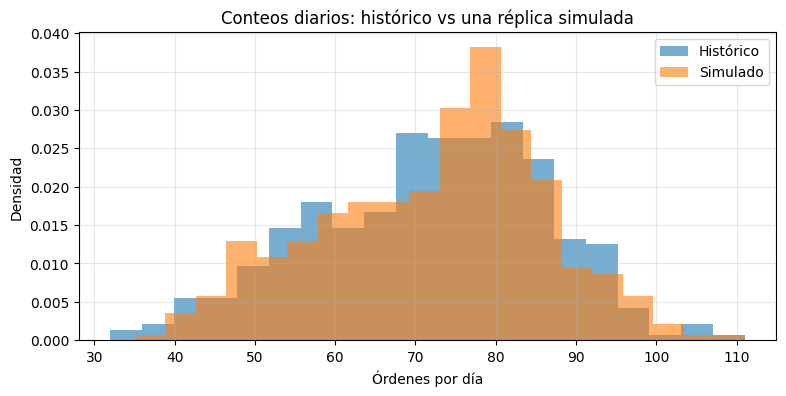

In [28]:
# Figura de validación: conteos diarios histórico vs una réplica simulada
one_rep_events, _ = simulate_laundry_year(seed=RNG_SEED + 11, return_events=True)
one_rep_daily = one_rep_events.groupby(one_rep_events["fecha_hora_llegada"].dt.floor("D")).size().reindex(calendar, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(daily_orders.values, bins=20, density=True, alpha=0.6, label="Histórico")
ax.hist(one_rep_daily.values, bins=20, density=True, alpha=0.6, label="Simulado")
ax.set_title("Conteos diarios: histórico vs una réplica simulada")
ax.set_xlabel("Órdenes por día")
ax.set_ylabel("Densidad")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 11. Escenarios interactivos

Modifique los parámetros de la celda siguiente y vuelva a ejecutarla:

- `rate_scale`: escala multiplicativa de llegadas. `1.10` representa 10% más demanda en todas las horas y días.
- `fast_multiplier`: escala multiplicativa de la probabilidad de servicio rápido por segmento. `1.25` representa 25% más propensión a servicio rápido, truncada a 95%.
- `n_reps`: número de réplicas para resumir el escenario.

Si su entorno tiene `ipywidgets`, la celda posterior crea controles deslizantes. Si no, use la función `evaluate_scenario(...)` directamente.

In [54]:
def evaluate_scenario(rate_scale=1.0, fast_multiplier=1.0, n_reps=100, seed=RNG_SEED + 1000):
    rng_master = np.random.default_rng(seed)
    rows = []
    for _ in range(int(n_reps)):
        rep_seed = int(rng_master.integers(0, 2**32 - 1))
        metrics = simulate_laundry_year(
            seed=rep_seed,
            rate_scale=float(rate_scale),
            fast_multiplier=float(fast_multiplier),
            return_events=False,
        )
        rows.append(demand_metrics_table(metrics))
    sims = pd.DataFrame(rows)
    summary = pd.DataFrame({
        "Media": sims.mean(),
        "P5": sims.quantile(0.05),
        "P95": sims.quantile(0.95),
    })
    display(Markdown(f"**Escenario:** rate_scale={rate_scale:.3f}, fast_multiplier={fast_multiplier:.3f}, réplicas={int(n_reps)}"))
    display(summary.round(3))
    return summary

# Escenario base editable
SCENARIO = {
    "rate_scale": 1.00,
    "fast_multiplier": 1.00,
    "n_reps": 100,
    "seed": RNG_SEED + 1000,
}
scenario_summary = evaluate_scenario(**SCENARIO)

**Escenario:** rate_scale=1.000, fast_multiplier=1.000, réplicas=100

,Media,P5,P95
Órdenes anuales,26260.050,25968.500,26555.550
Pedidos/día promedio,71.945,71.147,72.755
Pedidos/día desv. est.,14.413,13.668,15.099
Bolsas anuales,123683.400,122184.350,125331.250
Bolsas por orden,4.710,4.681,4.741
% servicio rápido,12.347,12.020,12.654
% hotel,33.633,33.225,34.046
% delicada,3.146,3.047,3.265
% color,21.305,21.021,21.553
% blanca,75.549,75.300,75.847


In [55]:
# Controles opcionales si el entorno tiene ipywidgets instalado.
try:
    import ipywidgets as widgets
    controls = widgets.interactive(
        evaluate_scenario,
        rate_scale=widgets.FloatSlider(value=1.0, min=0.7, max=1.5, step=0.05, description="Demanda"),
        fast_multiplier=widgets.FloatSlider(value=1.0, min=0.5, max=2.0, step=0.05, description="Rápido"),
        n_reps=widgets.IntSlider(value=50, min=20, max=300, step=10, description="Réplicas"),
        seed=widgets.IntText(value=RNG_SEED + 2000, description="Semilla"),
    )
    display(controls)
except Exception as e:
    print("ipywidgets no está disponible en este entorno. Use evaluate_scenario(rate_scale=..., fast_multiplier=..., n_reps=...) para explorar escenarios.")

interactive(children=(FloatSlider(value=1.0, description='Demanda', max=1.5, min=0.7, step=0.05), FloatSlider(…

## 12. Conclusiones metodológicas

1. La sobredispersión diaria agregada se explica principalmente por la mezcla de días de semana. Una vez condicionado el día de semana, la Poisson es suficiente para conteos diarios.
2. La binomial negativa por día de semana mejora la log-verosimilitud en una magnitud muy pequeña, pero añade siete parámetros extra; por AIC no compensa.
3. Para simulación de eventos, el modelo operativo correcto es horario: \(N(d,h)\sim Poisson(\lambda(w,h))\), con timestamps uniformes dentro de cada hora.
4. La estructura condicional de atributos es parsimoniosa y defendible: segmento depende de día/hora; servicio depende de segmento; bolsas dependen de segmento×servicio.
5. La composición debe preservar la suma de bolsas por tipo. La Dirichlet-multinomial captura heterogeneidad entre órdenes; restaurante·rápido es una excepción donde la multinomial simple basta.
6. El CSV modela entradas, no procesos internos. Para una simulación operativa completa faltan tiempos de lavado/secado/doblado, capacidades de máquinas, personal, reglas de prioridad y promesas de entrega.